# Multi-Objective Optimization - NSGA-II

In [1]:
import os
import time
import json
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import optuna
from optuna.samplers import NSGAIISampler, TPESampler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
try:
    from pymoo.indicators.hv import HV
    HAS_PYMOO = True
except ImportError:
    HAS_PYMOO = False

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
})


/home/debopriya/venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
N_TRIALS = 60
SEED = 42
DATA_DIR = "./data"
RESULTS_DIR = "./results"
FIGURES_DIR = "./report/figures"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)


## Dataset and Model Setup

In [3]:
def get_dataloaders(batch_size: int, input_resolution: int):
    tf = transforms.Compose([
        transforms.Resize((input_resolution, input_resolution)),
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,)),
    ])
    train_ds = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=tf)
    test_ds  = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, test_loader


In [4]:
class DynamicCNN(nn.Module):
    def __init__(self, n_conv_layers: int, channels: list[int], dropout_rate: float, input_resolution: int):
        super().__init__()
        conv_blocks = []
        in_ch = 1
        spatial = input_resolution

        for i in range(n_conv_layers):
            out_ch = channels[i]
            conv_blocks.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
            conv_blocks.append(nn.BatchNorm2d(out_ch))
            conv_blocks.append(nn.ReLU(inplace=True))
            conv_blocks.append(nn.MaxPool2d(2))
            in_ch = out_ch
            spatial = spatial // 2

        self.features = nn.Sequential(*conv_blocks)
        flat_dim = in_ch * spatial * spatial

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total

@torch.no_grad()
def measure_inference_time(model, loader, device, n_batches=10):
    model.eval()
    times = []
    for i, (X, _) in enumerate(loader):
        if i >= n_batches:
            break
        X = X.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model(X)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)
    return float(np.mean(times))


## Optimization

In [6]:
def objective(trial: optuna.Trial):
    n_conv_layers = trial.suggest_int("n_conv_layers", 1, 4)
    channels = [trial.suggest_categorical(f"channels_{i}", [16, 32, 48, 64, 96, 128]) for i in range(n_conv_layers)]
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    n_epochs = trial.suggest_int("n_epochs", 3, 15)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    optimizer_name = trial.suggest_categorical("optimizer_type", ["Adam", "SGD", "RMSprop"])
    input_resolution = trial.suggest_categorical("input_resolution", [16, 20, 24, 28])

    final_spatial = input_resolution // (2 ** n_conv_layers)
    if final_spatial < 1:
        raise optuna.TrialPruned()

    model = DynamicCNN(n_conv_layers, channels, dropout_rate, input_resolution).to(DEVICE)
    n_params = count_parameters(model)

    opt_map = {"Adam": optim.Adam, "SGD": optim.SGD, "RMSprop": optim.RMSprop}
    optimizer = opt_map[optimizer_name](model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    train_loader, test_loader = get_dataloaders(batch_size, input_resolution)

    for epoch in range(n_epochs):
        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    accuracy = evaluate(model, test_loader, DEVICE)
    inference_time = measure_inference_time(model, test_loader, DEVICE)

    return -accuracy, inference_time, n_params


In [7]:
print(f"Device: {DEVICE}")

sampler = NSGAIISampler(seed=SEED)
study = optuna.create_study(
    directions=["minimize", "minimize", "minimize"],
    sampler=sampler,
    study_name="MOO_FashionMNIST",
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

records = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        records.append({
            "trial": t.number,
            "accuracy": -t.values[0],
            "inference_ms": t.values[1],
            "n_parameters": int(t.values[2]),
            **t.params,
        })

df_all = pd.DataFrame(records)
df_all.to_csv(os.path.join(RESULTS_DIR, "all_trials.csv"), index=False)

pareto_records = []
for t in study.best_trials:
    pareto_records.append({
        "trial": t.number,
        "accuracy": -t.values[0],
        "inference_ms": t.values[1],
        "n_parameters": int(t.values[2]),
        **t.params,
    })

df_pareto = pd.DataFrame(pareto_records)
df_pareto.to_csv(os.path.join(RESULTS_DIR, "pareto_front.csv"), index=False)

meta = {
    "n_trials": N_TRIALS,
    "n_completed": len(df_all),
    "n_pareto": len(df_pareto),
    "device": str(DEVICE),
    "seed": SEED
}
with open(os.path.join(RESULTS_DIR, "study_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)


[I 2026-04-28 12:47:23,907] A new study created in memory with name: MOO_FashionMNIST


Device: cuda


100%|██████████| 26.4M/26.4M [00:04<00:00, 5.76MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 173kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.0MB/s]
  2%|▏         | 1/60 [01:01<1:00:24, 61.42s/it]

[I 2026-04-28 12:48:25,332] Trial 0 finished with values: [-0.9104, 0.49237776547670364, 458090.0] and parameters: {'n_conv_layers': 2, 'channels_0': 16, 'channels_1': 96, 'learning_rate': 0.0004335281794951569, 'batch_size': 256, 'n_epochs': 8, 'dropout_rate': 0.14561457009902096, 'optimizer_type': 'Adam', 'input_resolution': 24}.


  3%|▎         | 2/60 [02:16<1:06:53, 69.19s/it]

...

[I 2026-04-28 13:51:53,049] Trial 57 finished with values: [-0.8905, 0.578256300650537, 59066.0] and parameters: {'n_conv_layers': 4, 'channels_0': 32, 'channels_1': 64, 'channels_2': 32, 'channels_3': 48, 'learning_rate': 0.06252940793270145, 'batch_size': 64, 'n_epochs': 7, 'dropout_rate': 0.05793452976256486, 'optimizer_type': 'Adam', 'input_resolution': 28}.


 98%|█████████▊| 59/60 [1:06:43<01:19, 79.99s/it]

[I 2026-04-28 13:54:07,173] Trial 58 finished with values: [-0.9, 0.5329724866896868, 296394.0] and parameters: {'n_conv_layers': 4, 'channels_0': 96, 'channels_1': 64, 'channels_2': 128, 'channels_3': 128, 'learning_rate': 0.01735698209081424, 'batch_size': 32, 'n_epochs': 14, 'dropout_rate': 0.03380628179610745, 'optimizer_type': 'RMSprop', 'input_resolution': 20}.


100%|██████████| 60/60 [1:07:45<00:00, 67.75s/it]

[I 2026-04-28 13:55:08,971] Trial 59 finished with values: [-0.8722, 0.3844844177365303, 170314.0] and parameters: {'n_conv_layers': 2, 'channels_0': 64, 'channels_1': 64, 'learning_rate': 0.011079193990007919, 'batch_size': 32, 'n_epochs': 7, 'dropout_rate': 0.4647645721239129, 'optimizer_type': 'Adam', 'input_resolution': 16}.


## Analysis

In [8]:
def plot_3d_pareto(df_all, df_pareto):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(df_all["accuracy"], df_all["inference_ms"], df_all["n_parameters"] / 1e3, c="lightgray", alpha=0.4, s=20, label="Dominated")
    sc = ax.scatter(df_pareto["accuracy"], df_pareto["inference_ms"], df_pareto["n_parameters"] / 1e3, c=df_pareto["accuracy"], cmap="viridis", edgecolors="black", s=60, linewidths=0.5, label="Pareto-optimal")
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Inference Time (ms)")
    ax.set_zlabel("Parameters (x10^3)")
    fig.colorbar(sc, ax=ax, label="Accuracy", shrink=0.6, pad=0.1)
    ax.legend()
    plt.savefig(os.path.join(FIGURES_DIR, "pareto_3d.png"))
    plt.show()

def plot_pairwise(df_all, df_pareto):
    pairs = [
        ("accuracy", "inference_ms", "Accuracy", "Inference Time (ms)"),
        ("accuracy", "n_parameters", "Accuracy", "Parameters"),
        ("inference_ms", "n_parameters", "Inference Time (ms)", "Parameters"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    for ax, (x, y, xl, yl) in zip(axes, pairs):
        ax.scatter(df_all[x], df_all[y], c="lightgray", alpha=0.4, s=15, label="Dominated")
        ax.scatter(df_pareto[x], df_pareto[y], c="tab:red", edgecolors="black", s=40, linewidths=0.5, zorder=5, label="Pareto-optimal")
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "pareto_pairwise.png"))
    plt.show()

def plot_parallel_coordinates(df_pareto):
    cols = ["accuracy", "inference_ms", "n_parameters"]
    df_norm = df_pareto[cols].copy()
    for c in cols:
        mn, mx = df_norm[c].min(), df_norm[c].max()
        if mx - mn > 0:
            df_norm[c] = (df_norm[c] - mn) / (mx - mn)
        else:
            df_norm[c] = 0.5
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(cols))
    for _, row in df_norm.iterrows():
        ax.plot(x, row[cols].values, alpha=0.5, linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(["Accuracy", "Inference (ms)", "Parameters"])
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "parallel_coords.png"))
    plt.show()

def compute_hypervolume(df_pareto):
    obj = np.column_stack([-df_pareto["accuracy"].values, df_pareto["inference_ms"].values, df_pareto["n_parameters"].values])
    ref = np.array([0.0, obj[:, 1].max() * 1.1, obj[:, 2].max() * 1.1])
    if HAS_PYMOO:
        hv_indicator = HV(ref_point=ref)
        hv = hv_indicator(obj)
    else:
        pts = obj[:, :2]
        pts = pts[pts[:, 0].argsort()]
        hv = 0.0
        prev_y = ref[1]
        for p in pts:
            if p[1] < prev_y:
                hv += (ref[0] - p[0]) * (prev_y - p[1])
                prev_y = p[1]
    return hv, ref

def compute_spacing(df_pareto):
    obj = np.column_stack([df_pareto["accuracy"].values, df_pareto["inference_ms"].values, df_pareto["n_parameters"].values])
    mn, mx = obj.min(axis=0), obj.max(axis=0)
    rng = mx - mn
    rng[rng == 0] = 1.0
    obj_norm = (obj - mn) / rng
    n = len(obj_norm)
    if n < 2: return 0.0
    d = []
    for i in range(n):
        dists = [np.linalg.norm(obj_norm[i] - obj_norm[j]) for j in range(n) if j != i]
        d.append(min(dists))
    d = np.array(d)
    d_mean = d.mean()
    return np.sqrt(np.sum((d - d_mean) ** 2) / (n - 1))

def compute_spread(df_pareto):
    obj = np.column_stack([df_pareto["accuracy"].values, df_pareto["inference_ms"].values, df_pareto["n_parameters"].values])
    rng = obj.max(axis=0) - obj.min(axis=0)
    rng[rng == 0] = 1.0
    return np.prod(rng) ** (1.0 / len(rng))


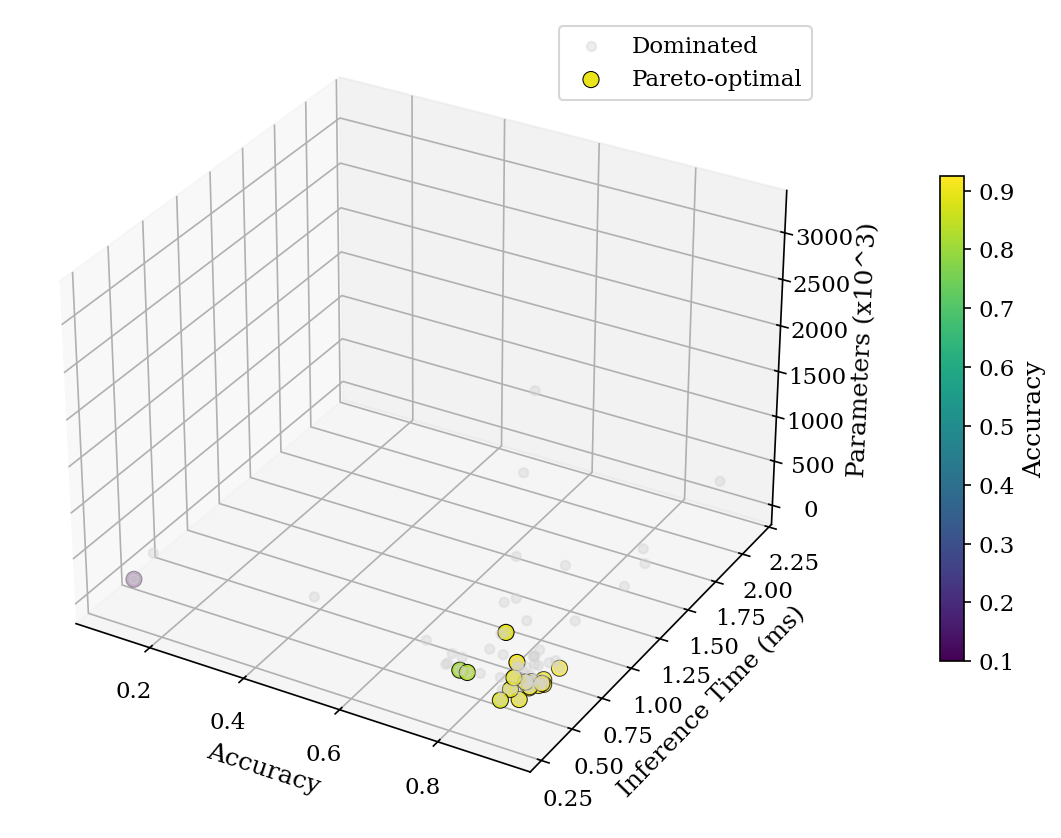

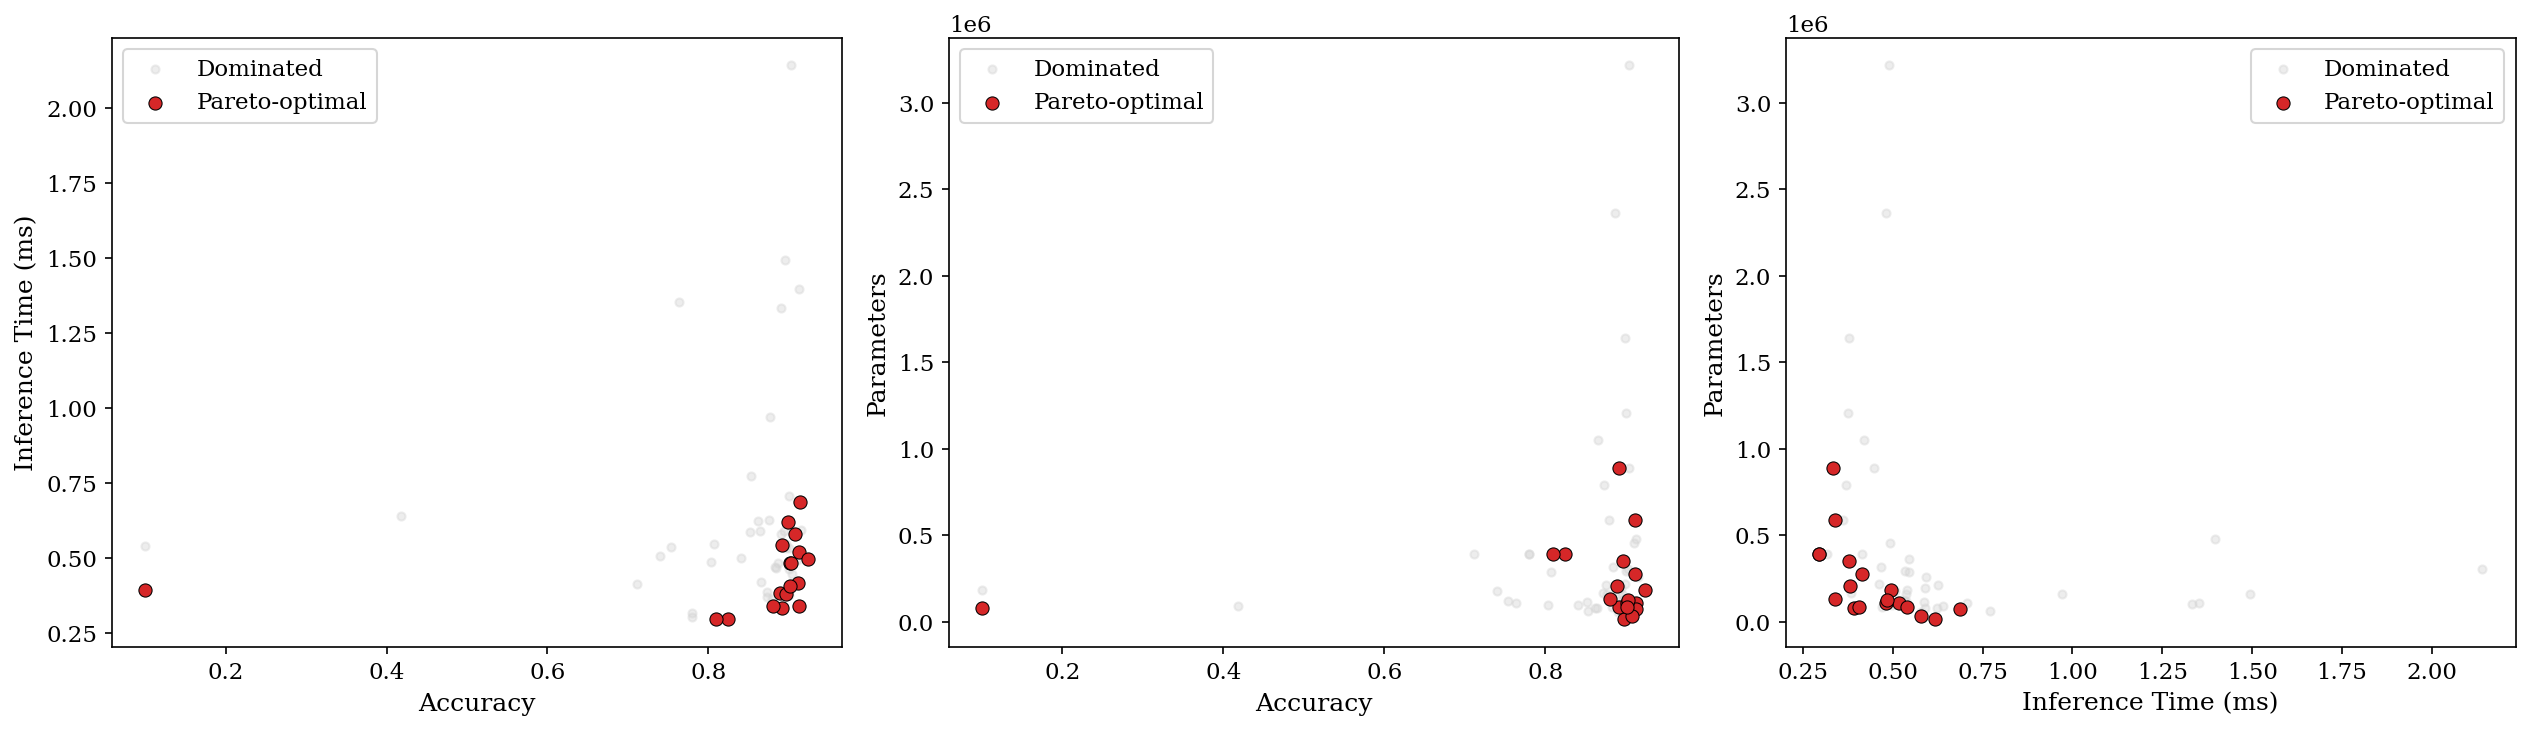

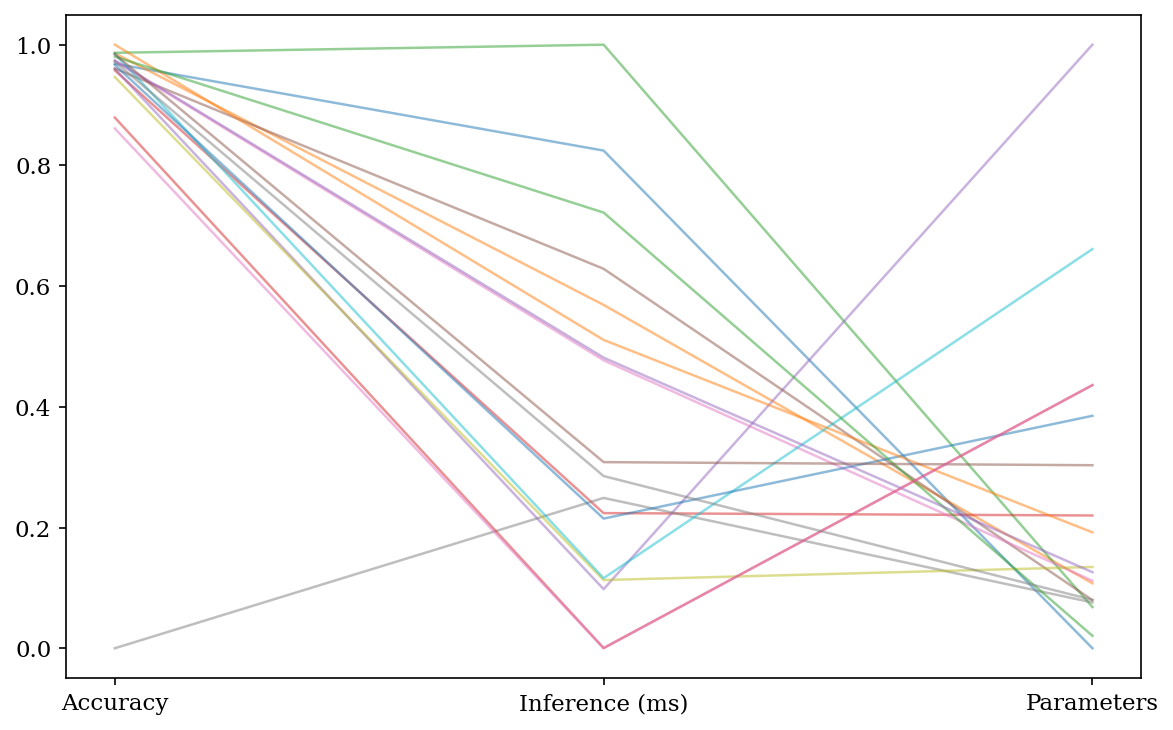

Hypervolume: 368466.4257790135
Spacing: 0.21678192057349596
Spread: 65.54221498239936

Pareto Front:
  trial  accuracy  inference_ms  n_parameters  n_conv_layers  channels_0  channels_1  channels_2  channels_3  learning_rate  batch_size  n_epochs  dropout_rate optimizer_type  input_resolution
    37    0.9243      0.494782        182714              3          96        96.0        48.0         NaN       0.000633          32        14      0.354181           Adam                28
    10    0.9132      0.686525         74842              4          16        64.0        48.0        64.0       0.008509         128        15      0.452675           Adam                24
     7    0.9125      0.517519        109066              3          64        64.0        64.0         NaN       0.000764          64        10      0.468077           Adam                20
    31    0.9119      0.340061        591626              1          32         NaN         NaN         NaN       0.000735        

In [9]:
df_all = pd.read_csv(os.path.join(RESULTS_DIR, "all_trials.csv"))
df_pareto = pd.read_csv(os.path.join(RESULTS_DIR, "pareto_front.csv"))

plot_3d_pareto(df_all, df_pareto)
plot_pairwise(df_all, df_pareto)
plot_parallel_coordinates(df_pareto)

hv, ref = compute_hypervolume(df_pareto)
spacing = compute_spacing(df_pareto)
spread = compute_spread(df_pareto)

metrics = {
    "hypervolume": float(hv),
    "spacing": float(spacing),
    "spread": float(spread),
    "n_pareto": len(df_pareto)
}
with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print("Hypervolume:", hv)
print("Spacing:", spacing)
print("Spread:", spread)
print("\nPareto Front:\n", df_pareto.sort_values("accuracy", ascending=False).to_string(index=False))
